In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
import sys
sys.path.insert(0, str(Path("..").resolve()))

from environment.retail_env import RetailEnv
from agents.dqn.dqn_agent import DQNAgent
from agents.ppo.ppo_agent import PPOAgent
from agents.a2c.a2c_agent import A2CAgent
from agents.qtable.qtable_agent import QTableAgent
from agents.baselines.baseline_agents import RandomAgent, FixedMarginAgent, AlwaysCheapestAgent
from utils.trainer import Trainer

sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (14, 5)
print("Ready")

Ready


In [2]:
# DQN — slower decay, more exploration
dqn_cfg = {
    'lr':             3e-5,      # was 1e-4, slower updates
    'gamma':          0.99,
    'batch_size':     128,
    'min_buffer':     500,
    'epsilon_start':  1.0,
    'epsilon_end':    0.10,      # was 0.05, keep more exploration
    'epsilon_decay':  50000,     # was 5000, much slower decay
    'buffer_size':    50000,
    'target_update':  1000,      # was 500
}

# PPO — same, working well
ppo_cfg = {
    'lr':          2e-4,
    'gamma':       0.99,
    'rollout_len': 64,
    'batch_size':  32,
    'n_epochs':    4,
    'clip_eps':    0.2,
    'ent_coef':    0.05,         # higher entropy = more exploration
}

# A2C — slower lr, more entropy
a2c_cfg = {
    'lr':        3e-4,           # was 7e-4
    'gamma':     0.99,
    'n_steps':   20,             # was 5, longer horizon
    'ent_coef':  0.05,           # was 0.01, more exploration
}

# QTable — same, working fine
qtab_cfg = {
    'lr':            0.05,       # was 0.1, slower updates
    'gamma':         0.99,
    'epsilon_start': 1.0,
    'epsilon_end':   0.05,
    'epsilon_decay': 20000,      # was 5000
}

In [3]:
N_EPISODES = 500    # small test run first
CUSTOMERS  = 2000

env = RetailEnv()
env.demand.base_daily_customers = CUSTOMERS

dqn_cfg  = {'lr': 3e-5, 'gamma': 0.99, 'batch_size': 128, 'min_buffer': 500,
             'epsilon_start': 1.0, 'epsilon_end': 0.10, 'epsilon_decay': 50000,
             'buffer_size': 50000, 'target_update': 1000}
ppo_cfg  = {'lr': 2e-4, 'gamma': 0.99, 'rollout_len': 64, 'batch_size': 32,
             'n_epochs': 4, 'clip_eps': 0.2, 'ent_coef': 0.05}
a2c_cfg  = {'lr': 3e-4, 'gamma': 0.99, 'n_steps': 20, 'ent_coef': 0.05}
qtab_cfg = {'lr': 0.05, 'gamma': 0.99, 'epsilon_start': 1.0,
             'epsilon_end': 0.05, 'epsilon_decay': 20000}

agents = {
    # original 4 RL agents
    'walmart':      DQNAgent(0,  'walmart',      716, 50, 'pure_revenue',            dqn_cfg,  seed=42),
    'target':       PPOAgent(1,  'target',        716, 50, 'profit_margin',           ppo_cfg,  seed=42),
    'amazon_fresh': A2CAgent(2,  'amazon_fresh',  716, 50, 'market_share',            a2c_cfg,  seed=42),
    'qfc':          QTableAgent(3,'qfc',           716, 50, 'revenue_with_inventory',  qtab_cfg, seed=42),
    # new RL agents replacing rule-based
    'safeway':      PPOAgent(4,  'safeway',       716, 50, 'long_term_value',         ppo_cfg,  seed=43),
    'kroger':       A2CAgent(5,  'kroger',        716, 50, 'promo_aware_profit',      a2c_cfg,  seed=43),
    'trader_joes':  DQNAgent(6,  'trader_joes',   716, 50, 'premium_floor',           dqn_cfg,  seed=43),
    'whole_foods':  PPOAgent(7,  'whole_foods',   716, 50, 'prestige_reward',         ppo_cfg,  seed=44),
    'aldi':         A2CAgent(8,  'aldi',          716, 50, 'discount_maximization',   a2c_cfg,  seed=44),
    'costco':       QTableAgent(9,'costco',        716, 50, 'bulk_volume',             qtab_cfg, seed=44),
}

trainer = Trainer(env, agents,
                  checkpoint_dir=Path("../checkpoints"),
                  save_every=5)
print(f"All 10 agents are RL agents")
print(f"Training {N_EPISODES} episodes × 365 days × {CUSTOMERS} customers")
for name, agent in agents.items():
    print(f"  {name:<15} {agent.__class__.__name__:<12} reward={agent.reward_fn}")

2026-03-02 21:51:27 | INFO     | environment.demand_model | MNLDemandModel (basket-level) initialized | customers=10000 | price_sensitivity=2.5 | brand_loyalty=0.59 | mean_basket_size=10
2026-03-02 21:51:27 | INFO     | environment.inventory | InventoryManager initialized | agents=10 | products=50 | initial_stock=500 | reorder_point=100
2026-03-02 21:51:27 | INFO     | environment.supply_chain | SupplyChain initialized | lead_time=2-7 days | disruption_prob=0.0001
2026-03-02 21:51:27 | INFO     | environment.promotions | PromotionCalendar initialized | 11 promo windows | weekend_multiplier=1.347
2026-03-02 21:51:27 | INFO     | environment.retail_env | RetailEnv initialized | agents=10 | products=50 | obs_size=716 | episode_length=365
2026-03-02 21:51:27 | INFO     | agents.base_agent.walmart | DQNAgent initialized | id=0 | reward_fn=pure_revenue
2026-03-02 21:51:27 | INFO     | agents.base_agent.walmart | DQNAgent initialized | id=0 | reward_fn=pure_revenue
2026-03-02 21:51:28 | INFO 

In [4]:
obs_dict, _ = env.reset()
for agent_name in env.agent_iter():
    obs, reward, term, trunc, info = env.last()
    if term or trunc:
        env.step(None)
        continue
    action = agents[agent_name].act(obs)
    env.step(action)
print("One episode completed successfully")

One episode completed successfully


In [5]:
results = trainer.train(n_episodes=5)

# check RL agents are actually learning
print(f"DQN epsilon:    {agents['walmart'].epsilon:.4f}  (should be < 1.0)")
print(f"DQN buffer:     {len(agents['walmart'].buffer)}  (should be > 0)")
print(f"DQN steps:      {agents['walmart'].total_steps}")
print(f"PPO rollout:    {len(agents['target'].rollout['rewards'])}  (fills up to 128)")
print(f"A2C buffer:     {len(agents['amazon_fresh'].buf['rewards'])}")

# check revenues are non-zero and different across agents
for r in results:
    top = sorted(r.revenues.items(), key=lambda x: x[1], reverse=True)[:3]
    print(f"Ep {r.episode} top 3: {[(n, f'${v:,.0f}') for n,v in top]}")

2026-03-02 21:54:35 | INFO     | agents.base_agent.walmart | DQN saved to ../checkpoints/walmart
2026-03-02 21:54:35 | INFO     | agents.base_agent.walmart | DQN saved to ../checkpoints/walmart
2026-03-02 21:54:35 | INFO     | agents.base_agent.trader_joes | DQN saved to ../checkpoints/trader_joes
2026-03-02 21:54:35 | INFO     | agents.base_agent.trader_joes | DQN saved to ../checkpoints/trader_joes
2026-03-02 21:54:35 | INFO     | utils.trainer | Episode 5 | top agents: [('qfc', '$16,956,392'), ('costco', '$13,276,376'), ('walmart', '$12,220,173')]
DQN epsilon:    0.9606  (should be < 1.0)
DQN buffer:     1820  (should be > 0)
DQN steps:      2190
PPO rollout:    0  (fills up to 128)
A2C buffer:     0
Ep 0 top 3: [('costco', '$8,726,701'), ('qfc', '$7,129,592'), ('trader_joes', '$6,674,081')]
Ep 1 top 3: [('trader_joes', '$10,516,510'), ('walmart', '$10,152,712'), ('safeway', '$9,847,422')]
Ep 2 top 3: [('costco', '$17,368,864'), ('trader_joes', '$14,402,111'), ('walmart', '$12,835,4

In [6]:
import time

results = []
start = time.time()

for ep in range(500):
    ep_start = time.time()
    result = trainer._run_episode(ep, training=True)
    results.append(result)
    ep_time = time.time() - ep_start
    elapsed = time.time() - start
    eta = (elapsed / (ep + 1)) * (500 - ep - 1)

    top = sorted(result.revenues.items(), key=lambda x: x[1], reverse=True)[:3]
    top_str = ", ".join([f"{n}=${v:,.0f}" for n, v in top])

    print(f"Ep {ep+1:>3}/500 | {ep_time:.1f}s | elapsed {elapsed/60:.1f}m | ETA {eta/60:.1f}m | {top_str}")

    # save checkpoints every 50 episodes
    if (ep + 1) % 50 == 0:
        trainer._save_checkpoints(ep)
        print(f"  ── checkpoint saved at episode {ep+1} ──")

print(f"\nDone! Total time: {(time.time()-start)/60:.1f} minutes")

Ep   1/500 | 30.6s | elapsed 0.5m | ETA 254.2m | trader_joes=$24,520,973, walmart=$21,668,791, costco=$17,528,472
Ep   2/500 | 30.3s | elapsed 1.0m | ETA 252.7m | costco=$15,067,761, trader_joes=$13,130,348, qfc=$13,074,384
Ep   3/500 | 29.8s | elapsed 1.5m | ETA 250.5m | qfc=$20,329,766, costco=$14,689,886, trader_joes=$14,486,152
Ep   4/500 | 29.4s | elapsed 2.0m | ETA 248.3m | trader_joes=$22,134,510, walmart=$21,623,349, costco=$15,874,737
Ep   5/500 | 29.9s | elapsed 2.5m | ETA 247.6m | walmart=$27,922,160, trader_joes=$24,188,673, qfc=$12,096,571
Ep   6/500 | 29.6s | elapsed 3.0m | ETA 246.5m | qfc=$20,155,876, walmart=$16,457,036, trader_joes=$11,519,249
Ep   7/500 | 29.6s | elapsed 3.5m | ETA 245.6m | walmart=$22,228,134, trader_joes=$21,804,096, qfc=$20,491,026
Ep   8/500 | 29.6s | elapsed 4.0m | ETA 244.8m | walmart=$33,956,190, trader_joes=$27,639,375, qfc=$22,075,568
Ep   9/500 | 29.3s | elapsed 4.5m | ETA 243.8m | trader_joes=$15,093,497, qfc=$14,938,711, walmart=$14,720,8

/var/folders/mf/pxwfzx596y5c99k9f98324k00000gn/T/ipykernel_45103/166606796.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(names, rotation=45, ha='right')


FileNotFoundError: [Errno 2] No such file or directory: '../results/training_curves.png'

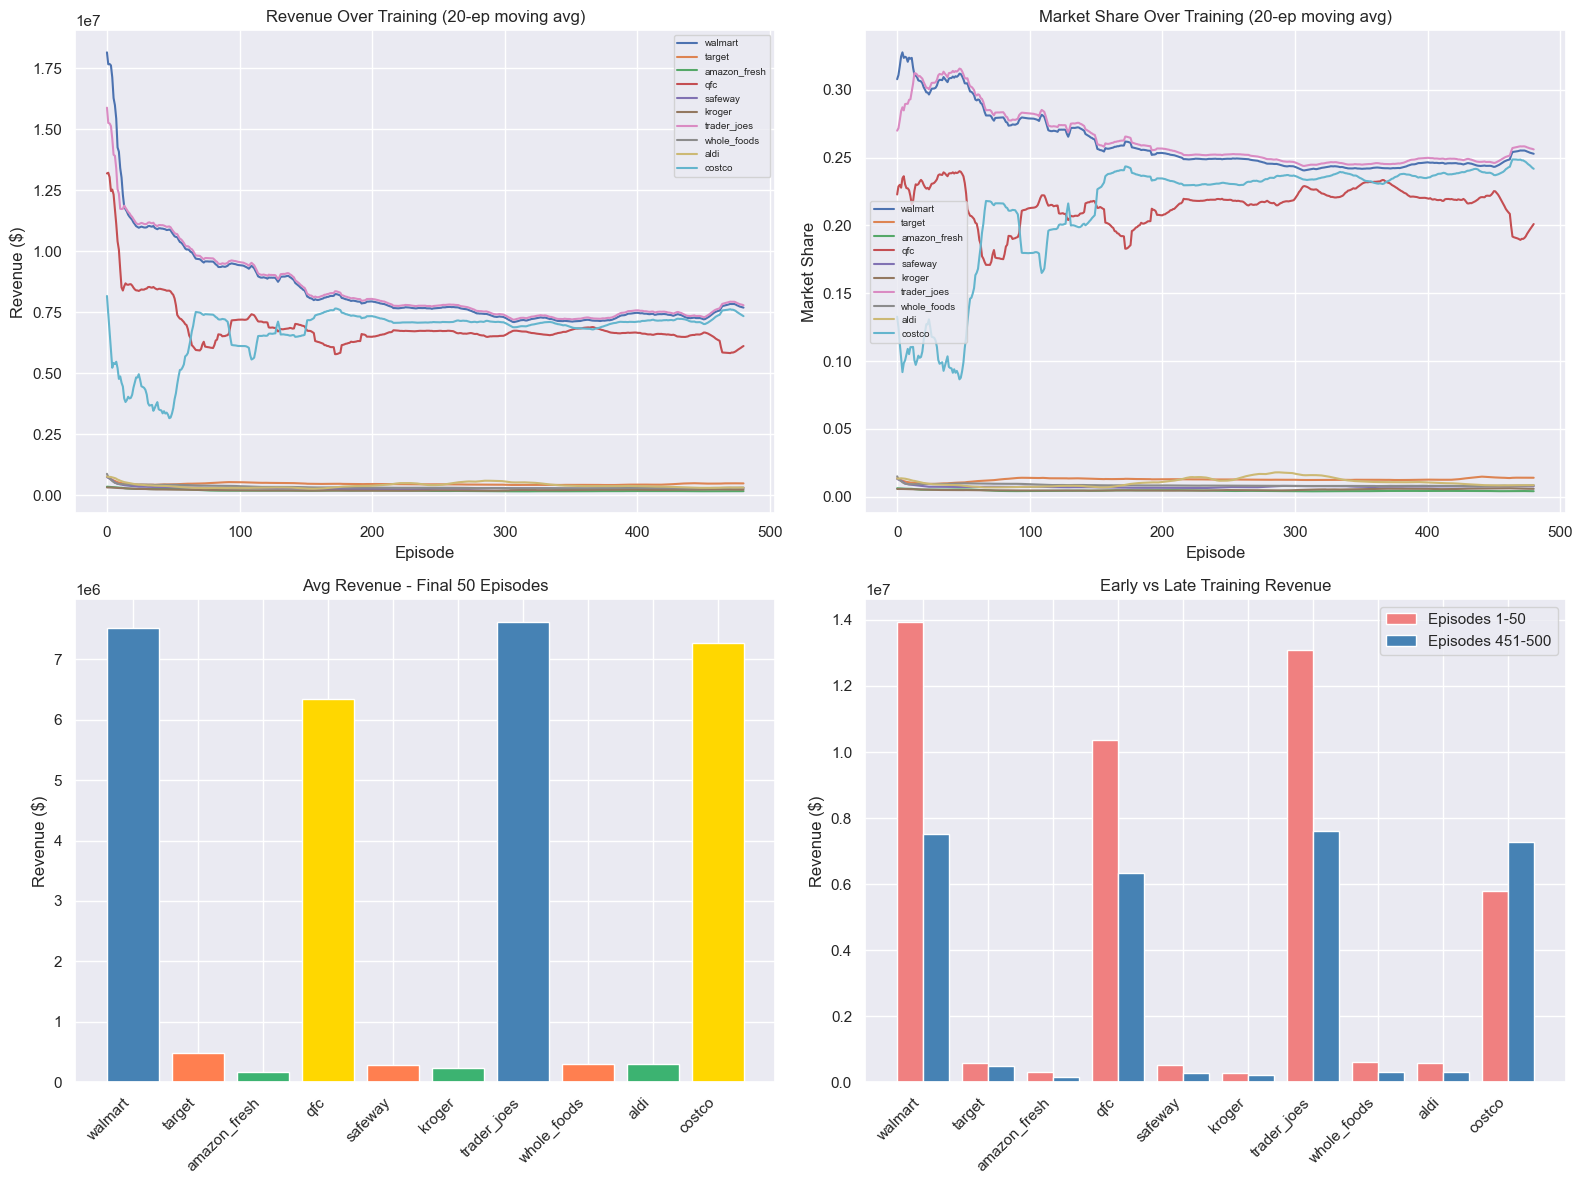

In [7]:
# revenue over training
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# --- Plot 1: Revenue over episodes (smoothed) ---
ax = axes[0, 0]
window = 20
for name in env.AGENT_NAMES:
    revs = [r.revenues.get(name, 0) for r in results]
    smoothed = np.convolve(revs, np.ones(window)/window, mode='valid')
    ax.plot(smoothed, label=name)
ax.set_title('Revenue Over Training (20-ep moving avg)')
ax.set_xlabel('Episode')
ax.set_ylabel('Revenue ($)')
ax.legend(fontsize=7)

# --- Plot 2: Market share over episodes (smoothed) ---
ax = axes[0, 1]
for name in env.AGENT_NAMES:
    shares = [r.market_shares.get(name, 0) for r in results]
    smoothed = np.convolve(shares, np.ones(window)/window, mode='valid')
    ax.plot(smoothed, label=name)
ax.set_title('Market Share Over Training (20-ep moving avg)')
ax.set_xlabel('Episode')
ax.set_ylabel('Market Share')
ax.legend(fontsize=7)

# --- Plot 3: Final 50 episode avg revenue by algorithm ---
ax = axes[1, 0]
final = results[-50:]
algo_revs = {}
for name in env.AGENT_NAMES:
    algo = agents[name].__class__.__name__
    avg = np.mean([r.revenues.get(name, 0) for r in final])
    algo_revs[name] = (algo, avg)
names = list(algo_revs.keys())
revs  = [algo_revs[n][1] for n in names]
algos = [algo_revs[n][0] for n in names]
colors = {'DQNAgent': 'steelblue', 'PPOAgent': 'coral', 'A2CAgent': 'mediumseagreen', 'QTableAgent': 'gold'}
ax.bar(names, revs, color=[colors.get(a, 'gray') for a in algos])
ax.set_title('Avg Revenue - Final 50 Episodes')
ax.set_xticklabels(names, rotation=45, ha='right')
ax.set_ylabel('Revenue ($)')

# --- Plot 4: Revenue early vs late comparison ---
ax = axes[1, 1]
early = results[:50]
late  = results[-50:]
x = np.arange(len(env.AGENT_NAMES))
early_revs = [np.mean([r.revenues.get(n, 0) for r in early]) for n in env.AGENT_NAMES]
late_revs  = [np.mean([r.revenues.get(n, 0) for r in late])  for n in env.AGENT_NAMES]
ax.bar(x - 0.2, early_revs, 0.4, label='Episodes 1-50',   color='lightcoral')
ax.bar(x + 0.2, late_revs,  0.4, label='Episodes 451-500', color='steelblue')
ax.set_title('Early vs Late Training Revenue')
ax.set_xticks(x)
ax.set_xticklabels(env.AGENT_NAMES, rotation=45, ha='right')
ax.set_ylabel('Revenue ($)')
ax.legend()

plt.tight_layout()
plt.savefig('../results/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to results/training_curves.png")

In [8]:
# check what the flat agents are actually optimizing
for name in ['amazon_fresh', 'whole_foods', 'safeway', 'target']:
    final = results[-50:]
    avg_reward = np.mean([r.total_rewards.get(name, 0) for r in final])
    avg_revenue = np.mean([r.revenues.get(name, 0) for r in final])
    avg_share = np.mean([r.market_shares.get(name, 0) for r in final])
    print(f"{name:<15} reward={avg_reward:>10.4f}  revenue=${avg_revenue:>10,.0f}  share={avg_share:.4f}")

amazon_fresh    reward=497297.8215  revenue=$   166,972  share=0.0040
whole_foods     reward=41390685.3143  revenue=$   300,950  share=0.0081
safeway         reward=82881146.0574  revenue=$   283,442  share=0.0076
target          reward=57249970.7035  revenue=$   483,692  share=0.0140


Setup complete.
Agents: ['walmart', 'target', 'amazon_fresh', 'qfc', 'safeway', 'kroger', 'trader_joes', 'whole_foods', 'aldi', 'costco']
Algorithms: {'walmart': 'DQNAgent', 'target': 'PPOAgent', 'amazon_fresh': 'A2CAgent', 'qfc': 'QTableAgent', 'safeway': 'PPOAgent', 'kroger': 'A2CAgent', 'trader_joes': 'DQNAgent', 'whole_foods': 'PPOAgent', 'aldi': 'A2CAgent', 'costco': 'QTableAgent'}
Reward fns: {'walmart': 'pure_revenue', 'target': 'profit_margin', 'amazon_fresh': 'market_share', 'qfc': 'revenue_with_inventory', 'safeway': 'long_term_value', 'kroger': 'promo_aware_profit', 'trader_joes': 'premium_floor', 'whole_foods': 'prestige_reward', 'aldi': 'discount_maximization', 'costco': 'bulk_volume'}
DataFrame shape: (5000, 7)
                 revenue  market_share  total_reward
agent                                               
aldi           403600.77          0.01  1.119804e+08
amazon_fresh   193806.42          0.00  5.461902e+05
costco        6799160.43          0.21  1.313827e+09


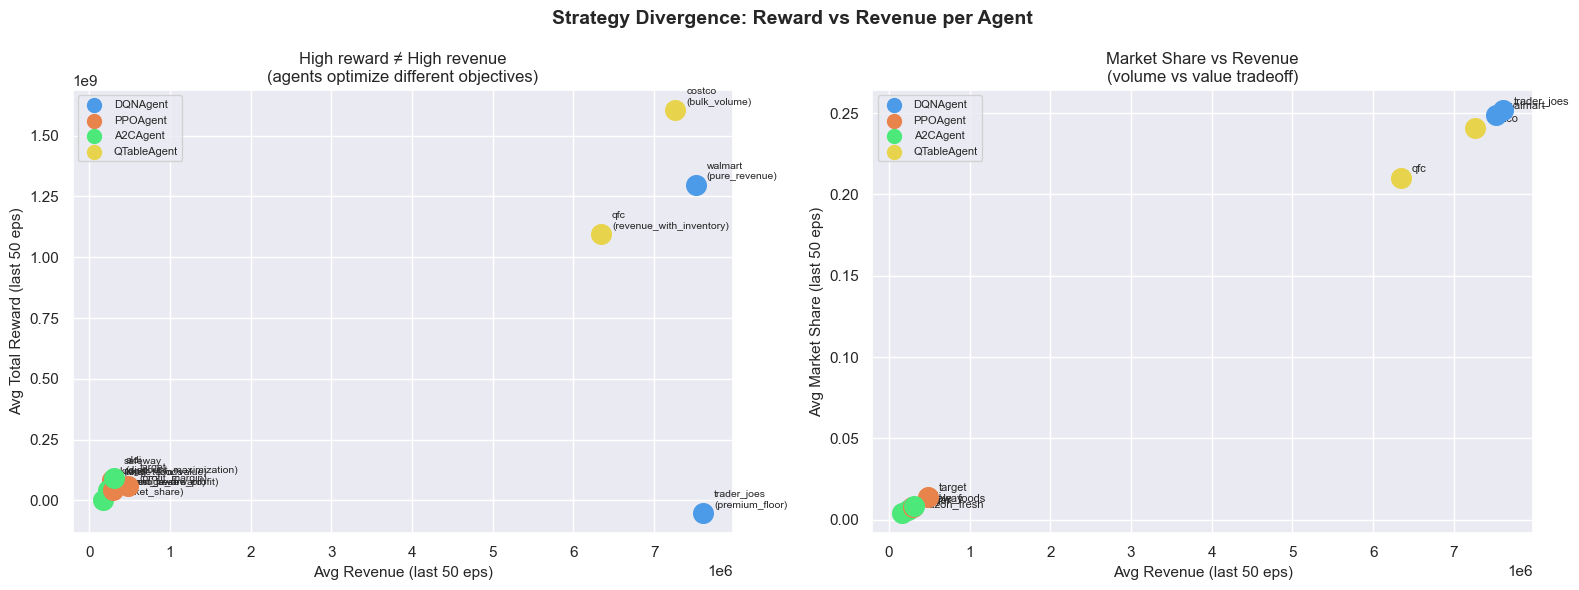

Saved: strategy_divergence.png


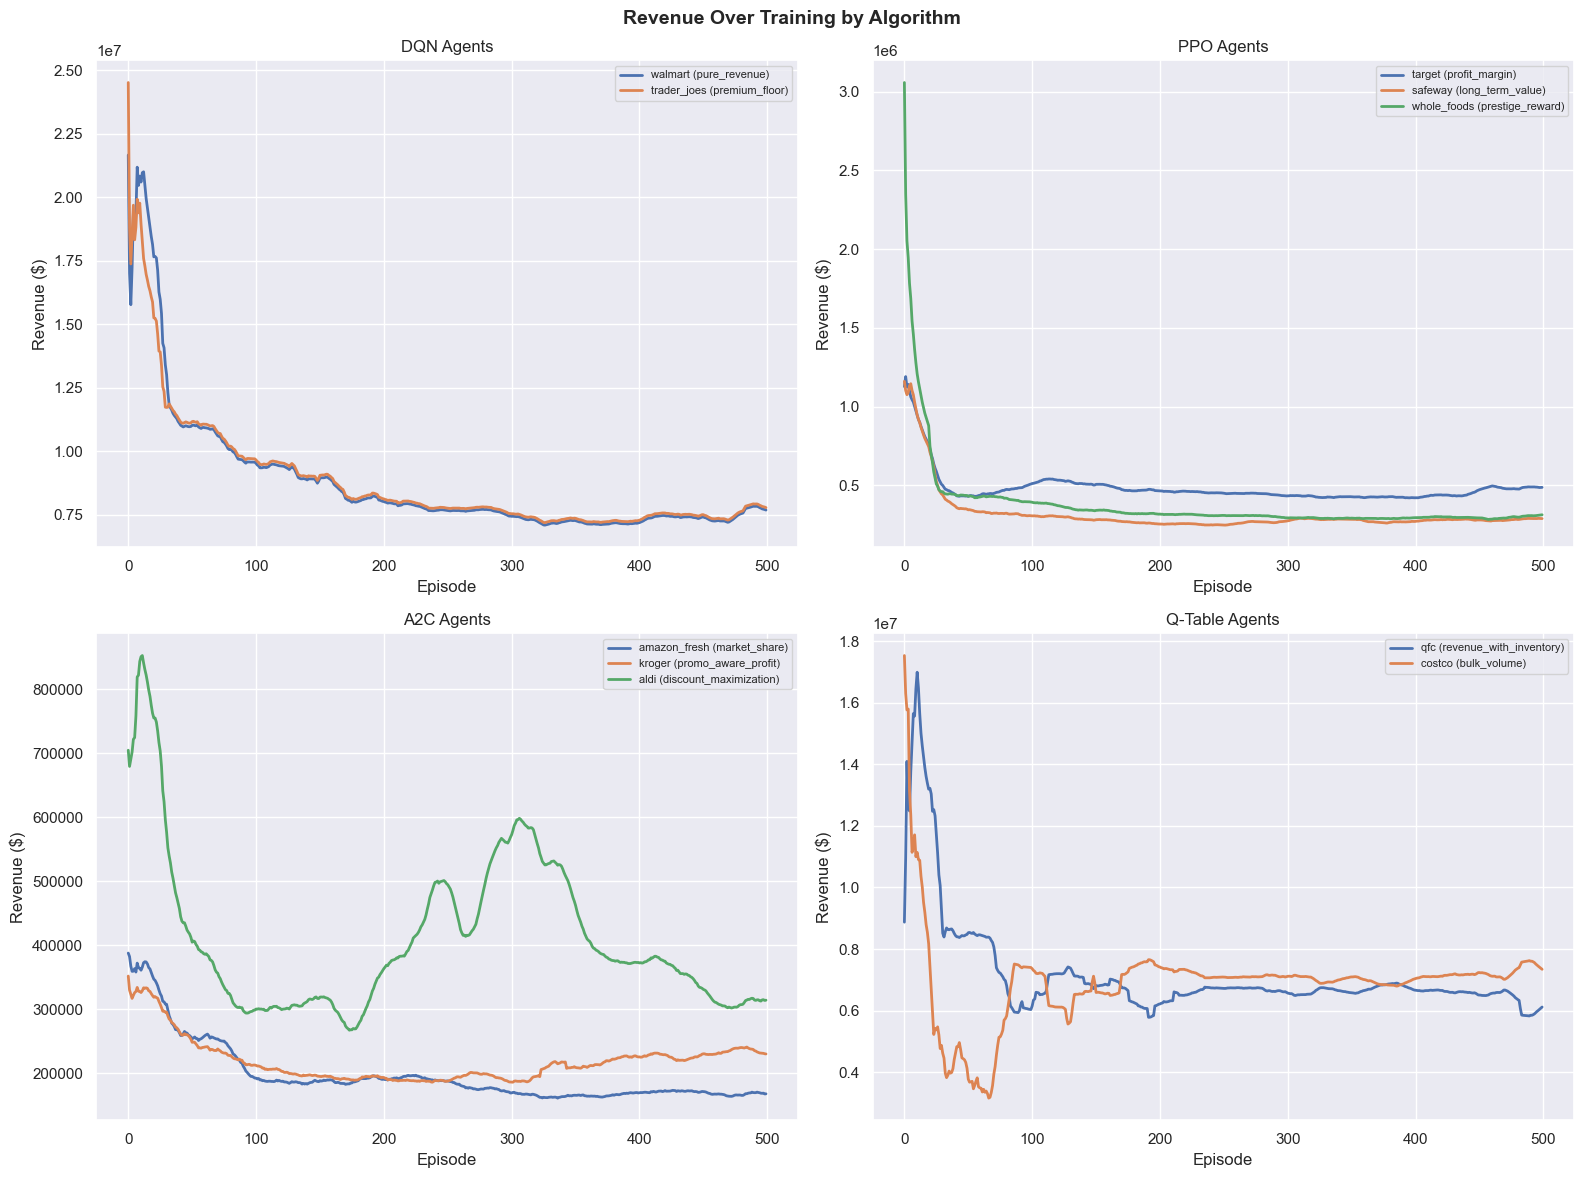

Saved: revenue_by_algorithm.png


/var/folders/mf/pxwfzx596y5c99k9f98324k00000gn/T/ipykernel_45103/597333363.py:182: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(AGENT_NAMES, rotation=45, ha='right', fontsize=8)


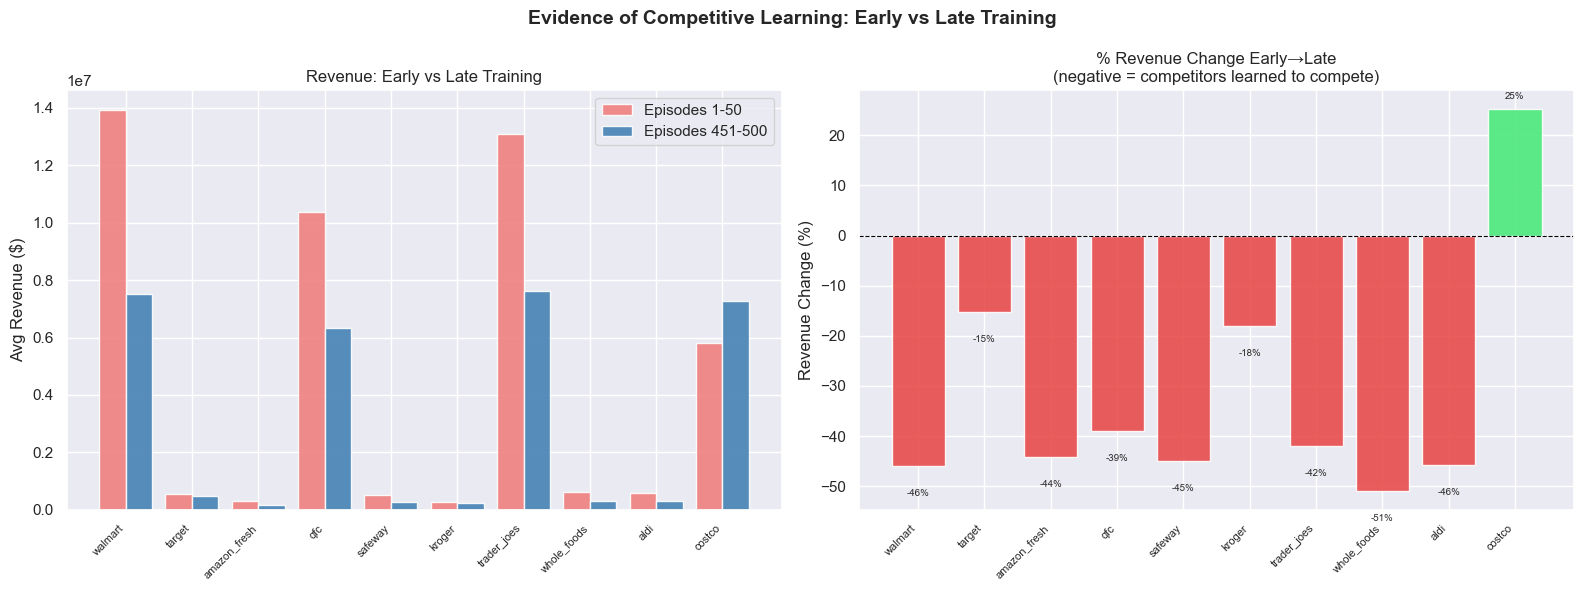

Saved: competitive_pressure.png


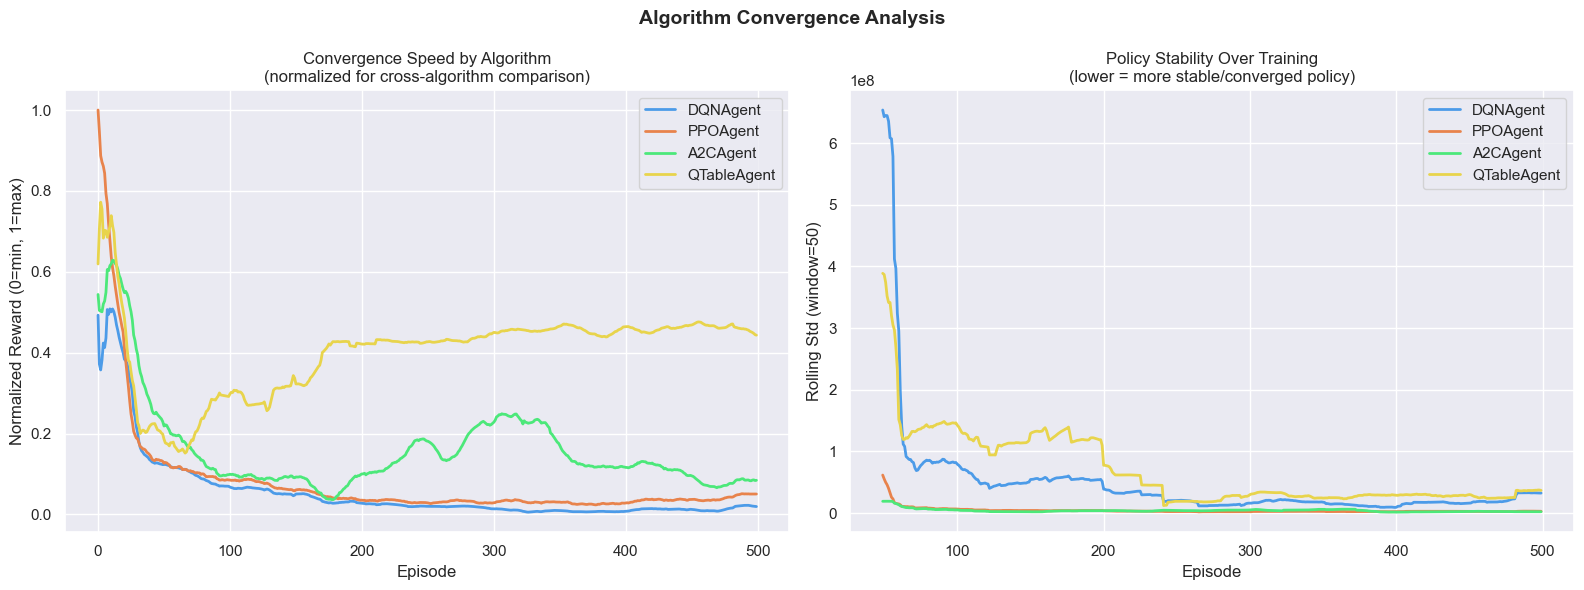

Saved: convergence_analysis.png


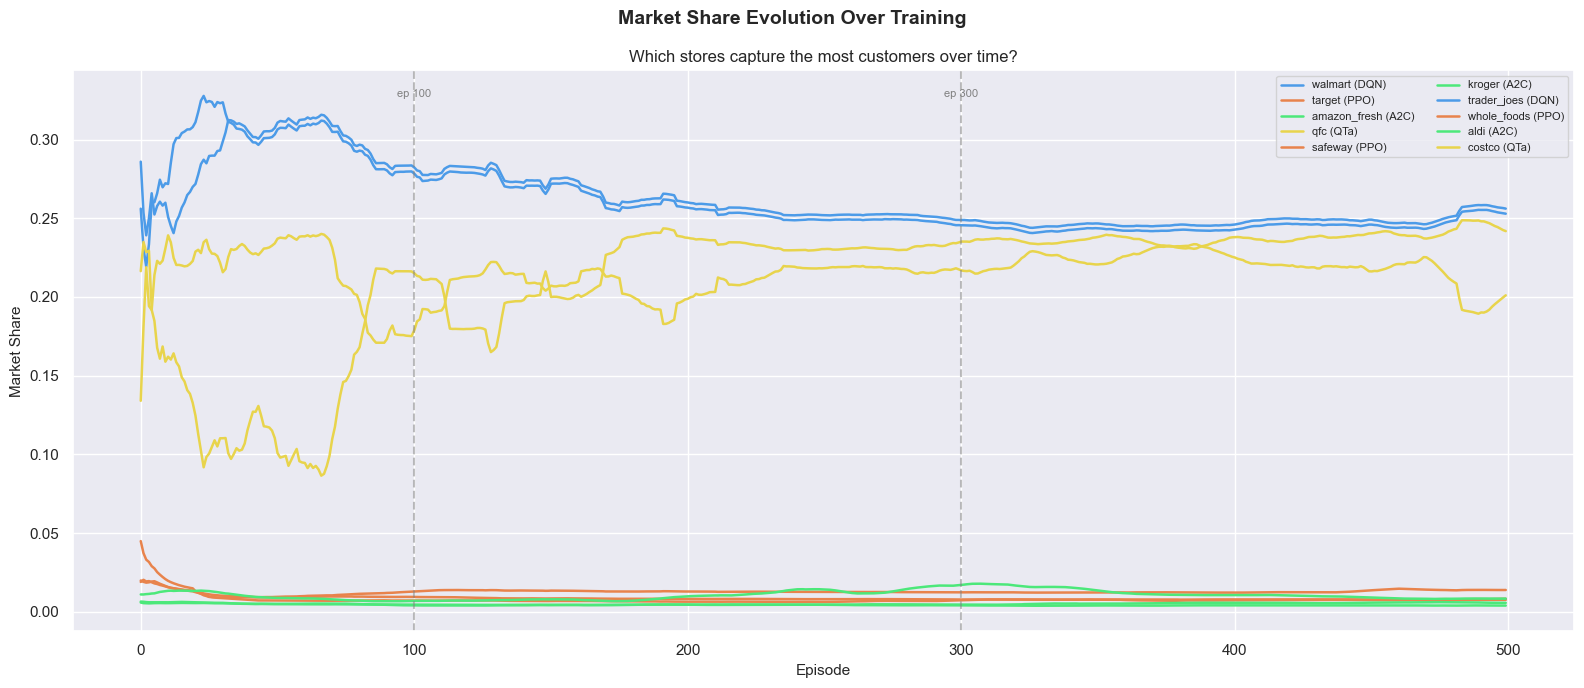

Saved: market_share_evolution.png

PHASE 6 SUMMARY — Final 50 Episodes
       Agent   Algorithm              Reward Fn Avg Revenue Avg Mkt Share    Avg Reward Rev Change
     walmart    DQNAgent           pure_revenue $ 7,515,823        0.2488 1,298,527,609     -46.0%
      target    PPOAgent          profit_margin $   483,692        0.0140    57,249,971     -15.2%
amazon_fresh    A2CAgent           market_share $   166,972        0.0040       497,298     -44.2%
         qfc QTableAgent revenue_with_inventory $ 6,341,964        0.2104 1,094,716,440     -38.9%
     safeway    PPOAgent        long_term_value $   283,442        0.0076    82,881,146     -44.9%
      kroger    A2CAgent     promo_aware_profit $   233,983        0.0060    40,771,099     -18.0%
 trader_joes    DQNAgent          premium_floor $ 7,608,193        0.2519   -52,375,083     -41.9%
 whole_foods    PPOAgent        prestige_reward $   300,950        0.0081    41,390,685     -50.9%
        aldi    A2CAgent  discount_max

In [9]:
"""
Phase 6: Results Analysis
=========================
Run this in your notebook (copy cells one by one) after Phase 5 training.
Assumes `results`, `agents`, `env` are already in scope from training.
"""

# ── Cell 1: Imports & Setup ───────────────────────────────────────────────────

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
from pathlib import Path

RESULTS_DIR = Path("../results")
RESULTS_DIR.mkdir(exist_ok=True)

AGENT_NAMES = env.AGENT_NAMES

ALGO_COLORS = {
    'DQNAgent':    '#4C9BE8',   # blue
    'PPOAgent':    '#E8834C',   # orange
    'A2CAgent':    '#4CE87A',   # green
    'QTableAgent': '#E8D44C',   # yellow
}

REWARD_FN = {name: agents[name].reward_fn for name in AGENT_NAMES}
ALGO      = {name: agents[name].__class__.__name__ for name in AGENT_NAMES}

print("Setup complete.")
print(f"Agents: {AGENT_NAMES}")
print(f"Algorithms: { {n: ALGO[n] for n in AGENT_NAMES} }")
print(f"Reward fns: { {n: REWARD_FN[n] for n in AGENT_NAMES} }")


# ── Cell 2: Build Summary DataFrame ──────────────────────────────────────────

rows = []
for i, r in enumerate(results):
    for name in AGENT_NAMES:
        rows.append({
            "episode":      i,
            "agent":        name,
            "algorithm":    ALGO[name],
            "reward_fn":    REWARD_FN[name],
            "revenue":      r.revenues.get(name, 0),
            "market_share": r.market_shares.get(name, 0),
            "total_reward": r.total_rewards.get(name, 0),
        })

df = pd.DataFrame(rows)

# smoothing helper
def smooth(series, window=20):
    return pd.Series(series).rolling(window, min_periods=1).mean().values

print(f"DataFrame shape: {df.shape}")
print(df.groupby('agent')[['revenue', 'market_share', 'total_reward']].mean().round(2))


# ── Cell 3: Plot 1 — Reward vs Revenue (Strategy Divergence) ─────────────────
# This is the KEY finding: agents optimizing different objectives

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Strategy Divergence: Reward vs Revenue per Agent', fontsize=14, fontweight='bold')

final_df = df[df['episode'] >= 450]
summary  = final_df.groupby('agent')[['total_reward', 'revenue', 'market_share']].mean()

# left: reward vs revenue scatter
ax = axes[0]
for name in AGENT_NAMES:
    color = ALGO_COLORS[ALGO[name]]
    x = summary.loc[name, 'revenue']
    y = summary.loc[name, 'total_reward']
    ax.scatter(x, y, color=color, s=200, zorder=5)
    ax.annotate(
        f"{name}\n({REWARD_FN[name]})",
        (x, y), textcoords="offset points",
        xytext=(8, 4), fontsize=7.5,
    )

# legend for algorithms
for algo, color in ALGO_COLORS.items():
    ax.scatter([], [], color=color, s=100, label=algo)
ax.legend(fontsize=8)
ax.set_xlabel('Avg Revenue (last 50 eps)', fontsize=11)
ax.set_ylabel('Avg Total Reward (last 50 eps)', fontsize=11)
ax.set_title('High reward ≠ High revenue\n(agents optimize different objectives)')
ax.yaxis.get_major_formatter().set_scientific(True)

# right: market share vs revenue scatter
ax = axes[1]
for name in AGENT_NAMES:
    color = ALGO_COLORS[ALGO[name]]
    x = summary.loc[name, 'revenue']
    y = summary.loc[name, 'market_share']
    ax.scatter(x, y, color=color, s=200, zorder=5)
    ax.annotate(
        name, (x, y),
        textcoords="offset points",
        xytext=(8, 4), fontsize=8,
    )

for algo, color in ALGO_COLORS.items():
    ax.scatter([], [], color=color, s=100, label=algo)
ax.legend(fontsize=8)
ax.set_xlabel('Avg Revenue (last 50 eps)', fontsize=11)
ax.set_ylabel('Avg Market Share (last 50 eps)', fontsize=11)
ax.set_title('Market Share vs Revenue\n(volume vs value tradeoff)')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'strategy_divergence.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: strategy_divergence.png")


# ── Cell 4: Plot 2 — Revenue Over Training (per algorithm group) ─────────────

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Revenue Over Training by Algorithm', fontsize=14, fontweight='bold')

algos = ['DQNAgent', 'PPOAgent', 'A2CAgent', 'QTableAgent']
algo_titles = {
    'DQNAgent':    'DQN Agents',
    'PPOAgent':    'PPO Agents',
    'A2CAgent':    'A2C Agents',
    'QTableAgent': 'Q-Table Agents',
}

for ax, algo in zip(axes.flat, algos):
    color = ALGO_COLORS[algo]
    algo_agents = [n for n in AGENT_NAMES if ALGO[n] == algo]
    for name in algo_agents:
        revs     = df[df['agent'] == name]['revenue'].values
        smoothed = smooth(revs, window=20)
        ax.plot(smoothed, label=f"{name} ({REWARD_FN[name]})", linewidth=2)
    ax.set_title(algo_titles[algo])
    ax.set_xlabel('Episode')
    ax.set_ylabel('Revenue ($)')
    ax.legend(fontsize=8)
    ax.yaxis.get_major_formatter().set_useOffset(False)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'revenue_by_algorithm.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: revenue_by_algorithm.png")


# ── Cell 5: Plot 3 — Competitive Pressure (Early vs Late) ────────────────────

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Evidence of Competitive Learning: Early vs Late Training', fontsize=14, fontweight='bold')

early = df[df['episode'] < 50]
late  = df[df['episode'] >= 450]

early_rev = early.groupby('agent')['revenue'].mean()
late_rev  = late.groupby('agent')['revenue'].mean()
pct_change = ((late_rev - early_rev) / early_rev.clip(lower=1)) * 100

# left: early vs late bar chart
ax = axes[0]
x = np.arange(len(AGENT_NAMES))
bars1 = ax.bar(x - 0.2, [early_rev.get(n, 0) for n in AGENT_NAMES],
               0.4, label='Episodes 1-50',   color='lightcoral', alpha=0.9)
bars2 = ax.bar(x + 0.2, [late_rev.get(n, 0)  for n in AGENT_NAMES],
               0.4, label='Episodes 451-500', color='steelblue',  alpha=0.9)
ax.set_xticks(x)
ax.set_xticklabels(AGENT_NAMES, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Avg Revenue ($)')
ax.set_title('Revenue: Early vs Late Training')
ax.legend()

# right: % change
ax = axes[1]
changes = [pct_change.get(n, 0) for n in AGENT_NAMES]
colors  = ['#E84C4C' if c < 0 else '#4CE87A' for c in changes]
ax.bar(AGENT_NAMES, changes, color=colors, alpha=0.9)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xticklabels(AGENT_NAMES, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Revenue Change (%)')
ax.set_title('% Revenue Change Early→Late\n(negative = competitors learned to compete)')
for i, (name, val) in enumerate(zip(AGENT_NAMES, changes)):
    ax.text(i, val + (2 if val >= 0 else -6), f'{val:.0f}%', ha='center', fontsize=7)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'competitive_pressure.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: competitive_pressure.png")


# ── Cell 6: Plot 4 — Algorithm Convergence Speed ─────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Algorithm Convergence Analysis', fontsize=14, fontweight='bold')

# left: reward convergence per algorithm (normalized)
ax = axes[0]
for algo in algos:
    algo_agents = [n for n in AGENT_NAMES if ALGO[n] == algo]
    all_rewards = np.array([
        df[df['agent'] == name]['total_reward'].values
        for name in algo_agents
    ])
    mean_reward = all_rewards.mean(axis=0)
    # normalize to [0,1] so different reward scales are comparable
    mn, mx = mean_reward.min(), mean_reward.max()
    if mx > mn:
        normalized = (mean_reward - mn) / (mx - mn)
    else:
        normalized = mean_reward * 0
    smoothed = smooth(normalized, window=20)
    ax.plot(smoothed, label=algo, color=ALGO_COLORS[algo], linewidth=2)

ax.set_xlabel('Episode')
ax.set_ylabel('Normalized Reward (0=min, 1=max)')
ax.set_title('Convergence Speed by Algorithm\n(normalized for cross-algorithm comparison)')
ax.legend()

# right: reward variance (stability) — lower = more stable/converged
ax = axes[1]
window = 50
for algo in algos:
    algo_agents = [n for n in AGENT_NAMES if ALGO[n] == algo]
    all_rewards = np.array([
        df[df['agent'] == name]['total_reward'].values
        for name in algo_agents
    ])
    mean_reward = all_rewards.mean(axis=0)
    rolling_std = pd.Series(mean_reward).rolling(window, min_periods=window).std().values
    ax.plot(rolling_std, label=algo, color=ALGO_COLORS[algo], linewidth=2)

ax.set_xlabel('Episode')
ax.set_ylabel(f'Rolling Std (window={window})')
ax.set_title('Policy Stability Over Training\n(lower = more stable/converged policy)')
ax.legend()

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'convergence_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: convergence_analysis.png")


# ── Cell 7: Plot 5 — Market Share Evolution ──────────────────────────────────

fig, ax = plt.subplots(figsize=(16, 7))
fig.suptitle('Market Share Evolution Over Training', fontsize=14, fontweight='bold')

for name in AGENT_NAMES:
    shares   = df[df['agent'] == name]['market_share'].values
    smoothed = smooth(shares, window=20)
    color    = ALGO_COLORS[ALGO[name]]
    ax.plot(smoothed, label=f"{name} ({ALGO[name][:3]})", color=color, linewidth=1.8)

ax.set_xlabel('Episode', fontsize=11)
ax.set_ylabel('Market Share', fontsize=11)
ax.set_title('Which stores capture the most customers over time?')
ax.legend(fontsize=8, ncol=2)
ax.axvline(100, color='gray', linestyle='--', alpha=0.5, label='ep 100')
ax.axvline(300, color='gray', linestyle='--', alpha=0.5, label='ep 300')
ax.text(100, ax.get_ylim()[1]*0.95, 'ep 100', ha='center', fontsize=8, color='gray')
ax.text(300, ax.get_ylim()[1]*0.95, 'ep 300', ha='center', fontsize=8, color='gray')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'market_share_evolution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: market_share_evolution.png")


# ── Cell 8: Summary Stats Table ───────────────────────────────────────────────

print("\n" + "="*80)
print("PHASE 6 SUMMARY — Final 50 Episodes")
print("="*80)

summary_rows = []
for name in AGENT_NAMES:
    agent_df  = df[(df['agent'] == name) & (df['episode'] >= 450)]
    early_df  = df[(df['agent'] == name) & (df['episode'] < 50)]
    summary_rows.append({
        "Agent":        name,
        "Algorithm":    ALGO[name],
        "Reward Fn":    REWARD_FN[name],
        "Avg Revenue":  f"${agent_df['revenue'].mean():>10,.0f}",
        "Avg Mkt Share":f"{agent_df['market_share'].mean():.4f}",
        "Avg Reward":   f"{agent_df['total_reward'].mean():>12,.0f}",
        "Rev Change":   f"{((agent_df['revenue'].mean() - early_df['revenue'].mean()) / max(early_df['revenue'].mean(), 1) * 100):>+.1f}%",
    })

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))
print("\nSaved all plots to:", RESULTS_DIR.resolve())

In [10]:
import pickle, json
from pathlib import Path

Path("../results").mkdir(exist_ok=True)

# save full results list
with open('../results/training_results.pkl', 'wb') as f:
    pickle.dump(results, f)

# also save as CSV for easy loading
df.to_csv('../results/training_results.csv', index=False)

# save agent metadata (algo + reward fn per agent)
agent_meta = {
    name: {
        'algorithm': agents[name].__class__.__name__,
        'reward_fn': agents[name].reward_fn,
    }
    for name in env.AGENT_NAMES
}
with open('../results/agent_meta.json', 'w') as f:
    json.dump(agent_meta, f, indent=2)

print("Saved:")
print("  results/training_results.pkl")
print("  results/training_results.csv")
print("  results/agent_meta.json")

Saved:
  results/training_results.pkl
  results/training_results.csv
  results/agent_meta.json


In [11]:
import json

# save per-episode revenue + market share for replay tab
episode_summaries = []
for i, r in enumerate(results):
    episode_summaries.append({
        "episode": i,
        "revenues": r.revenues,
        "market_shares": r.market_shares,
        "total_rewards": r.total_rewards,
    })

with open('../results/episode_summaries.json', 'w') as f:
    json.dump(episode_summaries, f)

print(f"Saved {len(episode_summaries)} episodes to episode_summaries.json")

Saved 500 episodes to episode_summaries.json
